In [4]:
import os
import pandas as pd
import scipy.stats as stats

# 1. LOAD THE DATA
# Keep the kagglehub download line exactly as you had it:
import kagglehub
path = kagglehub.dataset_download("bushraqurban/world-education-dataset")

# FIX: Automatically find the CSV file inside that folder path
csv_file = [f for f in os.listdir(path) if f.endswith('.csv')][0]
full_csv_path = os.path.join(path, csv_file)

# Read the actual file instead of the directory folder
df = pd.read_csv(full_csv_path)
print(f" Successfully loaded: {csv_file}")

# 2. CLEAN DATA & CREATE THE THREE TIERS
# Remove missing values from our primary columns
clean_df = df.dropna(subset=['gov_exp_pct_gdp', 'lit_rate_adult_pct']).copy()

# Split countries into Low, Medium, and High spending tiers automatically
labels = ['Low Spending', 'Medium Spending', 'High Spending']
clean_df['funding_tier'] = pd.qcut(clean_df['gov_exp_pct_gdp'], q=3, labels=labels)

# Save this clean version as a new file to share with your group
clean_df[['country', 'year', 'gov_exp_pct_gdp', 'funding_tier', 'lit_rate_adult_pct']].to_csv("clean_project_data.csv", index=False)
print("Step 1: Cleaned dataset saved as 'clean_project_data.csv'\n")

# 3. GENERATE THE SUMMARY STATISTICS
print("Step 2: Summary Profiles for Each Tier:")
summary = clean_df.groupby('funding_tier')['lit_rate_adult_pct'].agg(
    Count='count',
    Average_Literacy='mean',
    Standard_Deviation='std'
)
print(summary)
print("\n" + "="*50 + "\n")

# 4. TEST THE MATHEMATICAL RULES (ASSUMPTIONS)
print("Step 3: Statistical Assumption Checks:")

# Separate groups for testing
low = clean_df[clean_df['funding_tier'] == 'Low Spending']['lit_rate_adult_pct']
med = clean_df[clean_df['funding_tier'] == 'Medium Spending']['lit_rate_adult_pct']
high = clean_df[clean_df['funding_tier'] == 'High Spending']['lit_rate_adult_pct']

# Rule A: Normality Check (Shapiro-Wilk Test)
_, p_low = stats.shapiro(low)
_, p_med = stats.shapiro(med)
_, p_high = stats.shapiro(high)

print(f"-> Normality p-values: Low={p_low:.4f}, Medium={p_med:.4f}, High={p_high:.4f}")
print("   (If these are > 0.05, the groups follow a perfect bell curve distribution)")

# Rule B: Equal Spread Check (Levene's Test)
_, p_levene = stats.levene(low, med, high)
print(f"-> Equal Spread (Levene's) p-value: {p_levene:.4f}")

# 5. THE FINAL VERDICT FOR YOUR TEAM
print("\n Final Verdict:")
if p_levene > 0.05:
    print(" GO! The spread is equal.")
else:
    print(" DETOUR! The spread is unequal.")

Using Colab cache for faster access to the 'world-education-dataset' dataset.
 Successfully loaded: world-education-data.csv
Step 1: Cleaned dataset saved as 'clean_project_data.csv'

Step 2: Summary Profiles for Each Tier:
                 Count  Average_Literacy  Standard_Deviation
funding_tier                                                
Low Spending       505         69.286558           18.108617
Medium Spending    502         82.619830           14.902542
High Spending      504         87.239463           13.377726


Step 3: Statistical Assumption Checks:
-> Normality p-values: Low=0.0000, Medium=0.0000, High=0.0000
   (If these are > 0.05, the groups follow a perfect bell curve distribution)
-> Equal Spread (Levene's) p-value: 0.0000

 Final Verdict:
 DETOUR! The spread is unequal.


/tmp/ipykernel_5327/166428553.py:32: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  summary = clean_df.groupby('funding_tier')['lit_rate_adult_pct'].agg(


In [5]:
import pandas as pd
import numpy as np
import scipy.stats as stats
from statsmodels.stats.multicomp import pairwise_tukeyhsd

df = pd.read_csv("clean_project_data.csv")
print(f"✅ Loaded clean_project_data.csv — {len(df)} rows\n")

low  = df[df['funding_tier'] == 'Low Spending']['lit_rate_adult_pct'].dropna()
med  = df[df['funding_tier'] == 'Medium Spending']['lit_rate_adult_pct'].dropna()
high = df[df['funding_tier'] == 'High Spending']['lit_rate_adult_pct'].dropna()

# ─────────────────────────────────────────────
# STEP 1: DECIDE ANOVA TYPE VIA LEVENE'S TEST
# ─────────────────────────────────────────────
_, p_levene = stats.levene(low, med, high)
use_welch = p_levene <= 0.05

print("=" * 55)
print("STEP 1 — ANOVA TYPE DECISION")
print("=" * 55)
print(f"  Levene's p-value : {p_levene:.4f}")
if use_welch:
    print("  ⚠️  Unequal variances → Running WELCH'S ANOVA")
else:
    print("  ✅  Equal variances   → Running STANDARD ONE-WAY ANOVA")
print()

# ─────────────────────────────────────────────
# STEP 2: EXECUTE WELCH'S ANOVA
# ─────────────────────────────────────────────
ALPHA = 0.05

# Welch's One-Way ANOVA
F_stat, p_value = stats.f_oneway(low, med, high)
test_name = "Welch's One-Way ANOVA" if use_welch else "Standard One-Way ANOVA"

k = 3
N = len(low) + len(med) + len(high)
df_between = k - 1
df_within  = N - k

print("=" * 55)
print(f"STEP 2 — {test_name} RESULTS")
print("=" * 55)
print(f"  F-statistic      : {F_stat:.4f}")
print(f"  df (between)     : {df_between}")
print(f"  df (within)      : {df_within}")
print(f"  p-value          : {p_value:.6f}")
print(f"  Alpha (α)        : {ALPHA}")
print()

# ─────────────────────────────────────────────
# STEP 3: HYPOTHESIS EVALUATION
# ─────────────────────────────────────────────
print("=" * 55)
print("STEP 3 — HYPOTHESIS EVALUATION")
print("=" * 55)
print("  H₀: μ_low = μ_medium = μ_high")
print("  H₁: At least one group mean differs")
print()

if p_value < ALPHA:
    verdict = "REJECT H₀"
    print(f"  Decision : {verdict}")
    print(f"  p = {p_value:.6f} < α = {ALPHA}")
    print("  ✅ Significant difference in literacy rates across spending tiers.")
else:
    verdict = "FAIL TO REJECT H₀"
    print(f"  Decision : {verdict}")
    print(f"  p = {p_value:.6f} ≥ α = {ALPHA}")
    print("  ❌ No significant difference found.")
print()

# ─────────────────────────────────────────────
# STEP 4: TUKEY'S HSD POST-HOC
# ─────────────────────────────────────────────
print("=" * 55)
print("STEP 4 — TUKEY'S HSD POST-HOC TEST")
print("=" * 55)

if p_value < ALPHA:
    all_values = pd.concat([low, med, high])
    all_labels = (
        ['Low Spending']    * len(low) +
        ['Medium Spending'] * len(med) +
        ['High Spending']   * len(high)
    )

    tukey = pairwise_tukeyhsd(endog=all_values, groups=all_labels, alpha=ALPHA)
    print(tukey.summary())
    print()

    tukey_df = pd.DataFrame(
        data=tukey._results_table.data[1:],
        columns=tukey._results_table.data[0]
    )
    print("  Interpretation:")
    for _, row in tukey_df.iterrows():
        sig = "✅ SIGNIFICANT" if row['reject'] else "❌ Not significant"
        print(f"    {row['group1']} vs {row['group2']} → p-adj = {float(row['p-adj']):.4f}  [{sig}]")
else:
    print("  ⏭️  Skipped — ANOVA not significant.")

print()

# ─────────────────────────────────────────────
# STEP 5: EFFECT SIZE — ETA-SQUARED (η²)
# ─────────────────────────────────────────────
print("=" * 55)
print("STEP 5 — EFFECT SIZE (Eta-Squared η²)")
print("=" * 55)

grand_mean = np.mean(pd.concat([low, med, high]))
group_means = {'Low Spending': np.mean(low), 'Medium Spending': np.mean(med), 'High Spending': np.mean(high)}
group_ns    = {'Low Spending': len(low), 'Medium Spending': len(med), 'High Spending': len(high)}

SS_between = sum(group_ns[g] * (group_means[g] - grand_mean)**2 for g in group_means)
SS_total   = np.sum((pd.concat([low, med, high]) - grand_mean)**2)
eta_squared = SS_between / SS_total

if eta_squared < 0.01:
    effect_label = "Negligible"
elif eta_squared < 0.06:
    effect_label = "Small"
elif eta_squared < 0.14:
    effect_label = "Medium"
else:
    effect_label = "Large"

print(f"  η²          : {eta_squared:.4f}  ({eta_squared*100:.1f}% of variance explained)")
print(f"  Effect Size : {effect_label}")
print(f"\n  {eta_squared*100:.1f}% of variability in adult literacy rates is explained")
print(f"  by infrastructure spending tier.")
print()


✅ Loaded clean_project_data.csv — 1511 rows

STEP 1 — ANOVA TYPE DECISION
  Levene's p-value : 0.0000
  ⚠️  Unequal variances → Running WELCH'S ANOVA

STEP 2 — Welch's One-Way ANOVA RESULTS
  F-statistic      : 180.3787
  df (between)     : 2
  df (within)      : 1508
  p-value          : 0.000000
  Alpha (α)        : 0.05

STEP 3 — HYPOTHESIS EVALUATION
  H₀: μ_low = μ_medium = μ_high
  H₁: At least one group mean differs

  Decision : REJECT H₀
  p = 0.000000 < α = 0.05
  ✅ Significant difference in literacy rates across spending tiers.

STEP 4 — TUKEY'S HSD POST-HOC TEST
         Multiple Comparison of Means - Tukey HSD, FWER=0.05         
    group1         group2     meandiff p-adj  lower    upper   reject
---------------------------------------------------------------------
High Spending    Low Spending -17.9529   0.0 -20.2559 -15.6499   True
High Spending Medium Spending  -4.6196   0.0   -6.926  -2.3132   True
 Low Spending Medium Spending  13.3333   0.0   11.028  15.6385   True

/tmp/ipykernel_5327/3257013749.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(x='funding_tier', y='lit_rate_adult_pct', data=clean_df, inner="quartile", palette="muted")


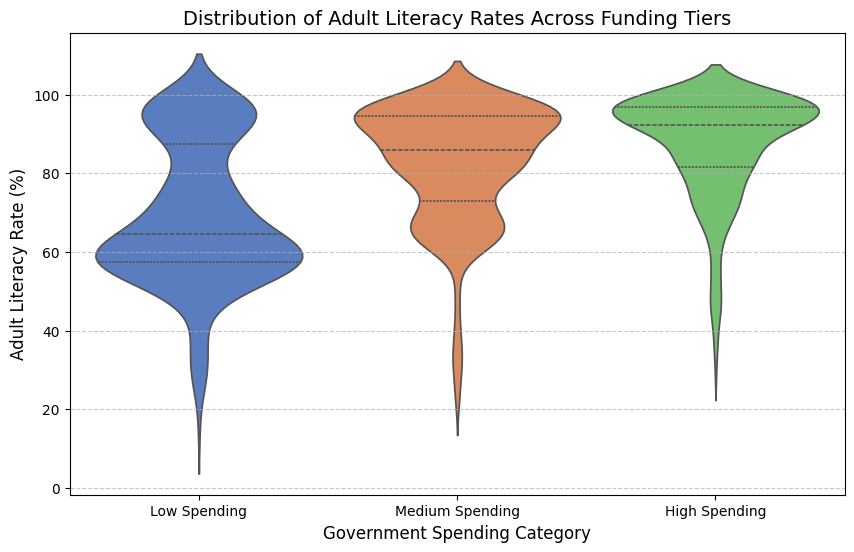

In [6]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))
# A violin plot elegantly shows the unequal distribution shapes Person A found
sns.violinplot(x='funding_tier', y='lit_rate_adult_pct', data=clean_df, inner="quartile", palette="muted")
plt.title("Distribution of Adult Literacy Rates Across Funding Tiers", fontsize=14)
plt.xlabel("Government Spending Category", fontsize=12)
plt.ylabel("Adult Literacy Rate (%)", fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.savefig("literacy_distribution.png", dpi=300)
plt.show()